Постройте график данного временного ряда
Удалите выбросы
Постройте модель временного ряда методом двойного экспоненциального сглаживания и подберите ее параметры

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

df = pd.read_csv('time_series_hw.csv')
series = df.set_index('date')['value']

print(series.head())
print(f"Длина ряда: {len(series)}")

date
1/1/1985    72.5052
2/1/1985    70.6720
3/1/1985    62.4502
4/1/1985    57.4714
5/1/1985    55.3151
Name: value, dtype: float64
Длина ряда: 397


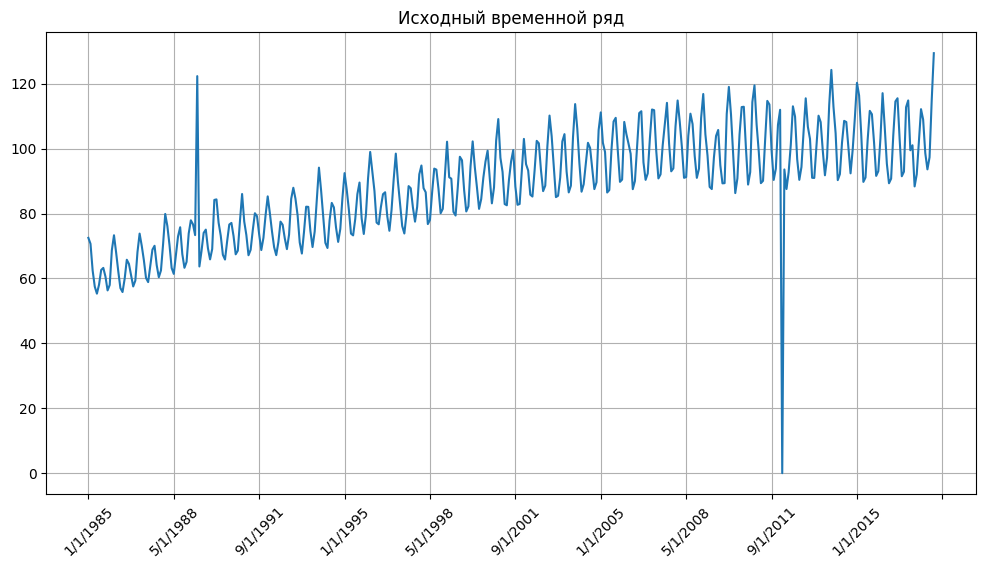

In [7]:
# График исходного ряда
plt.figure(figsize=(12, 6))
plt.plot(series)
plt.title('Исходный временной ряд')
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.show()

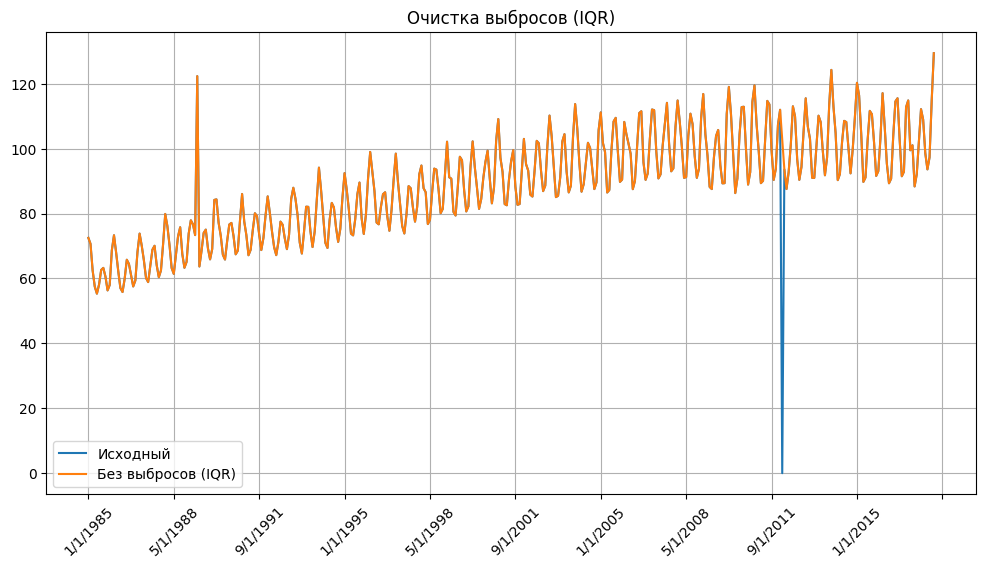

In [8]:
# Удаление выбросов
Q1 = series.quantile(0.25)
Q3 = series.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

series_clean = series.copy()
series_clean[(series < lower) | (series > upper)] = np.nan
series_clean = series_clean.interpolate()

plt.figure(figsize=(12, 6))
plt.plot(series, label='Исходный')
plt.plot(series_clean, label='Без выбросов (IQR)')
plt.legend()
plt.grid(True)
plt.title('Очистка выбросов (IQR)')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.show()

In [9]:
from statsmodels.tsa.holtwinters import Holt

model = Holt(series_clean).fit(optimized=True)
print(model.params)

{'smoothing_level': np.float64(0.9999999850988388), 'smoothing_trend': np.float64(0.008226729137452166), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(72.5052), 'initial_trend': np.float64(-1.833200000000005), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


C:\Users\Lizam\PyCharmMiscProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


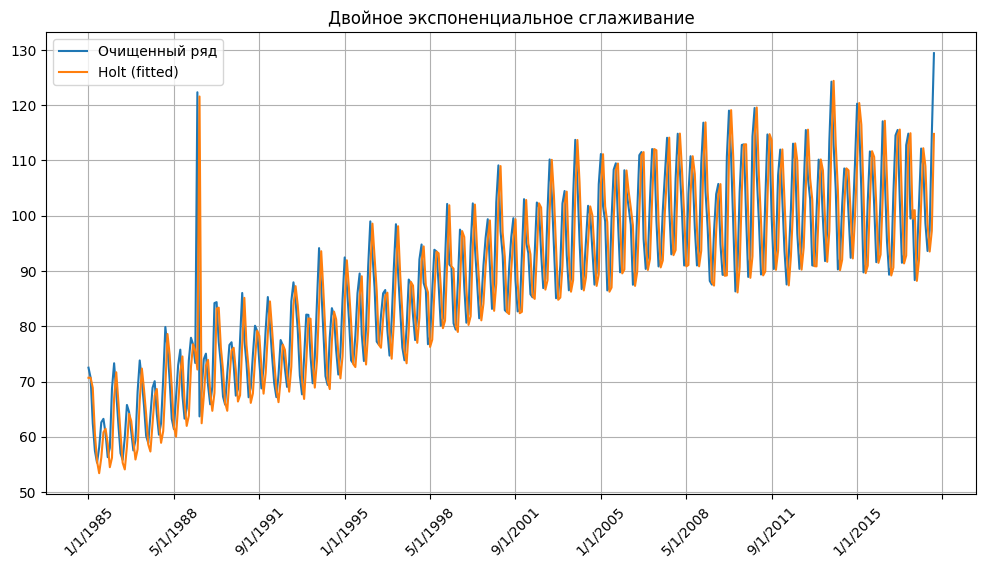

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(series_clean, label='Очищенный ряд')
plt.plot(model.fittedvalues, label='Holt (fitted)')
plt.legend()
plt.grid(True)
plt.title('Двойное экспоненциальное сглаживание')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.show()